In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# Criação do dataset sintético

np.random.seed(42)

n = 500

temperatura = np.random.randint(15, 45, n)
umidade = np.random.randint(10, 100, n)
chuva_mm = np.random.randint(0, 200, n)
vegetacao = np.random.randint(0, 100, n)
focos_calor = np.random.randint(0, 10, n)

risco = []

for i in range(n):

    score = 0

    if temperatura[i] > 35:
        score += 2

    if umidade[i] < 30:
        score += 2

    if chuva_mm[i] < 20:
        score += 2

    if vegetacao[i] < 30:
        score += 2

    if focos_calor[i] > 5:
        score += 2

    if score <= 2:
        risco.append("Baixo")
    elif score <= 5:
        risco.append("Medio")
    else:
        risco.append("Alto")

df = pd.DataFrame({
    "temperatura": temperatura,
    "umidade": umidade,
    "chuva_mm": chuva_mm,
    "vegetacao": vegetacao,
    "focos_calor": focos_calor,
    "risco_ambiental": risco
})

df.head()

,temperatura,umidade,chuva_mm,vegetacao,focos_calor,risco_ambiental
0,21,51,2,86,3,Baixo
1,34,35,110,85,8,Baixo
2,43,59,150,84,5,Baixo
3,29,34,106,26,8,Medio
4,25,33,17,56,5,Baixo


In [26]:
# Exportação do dataset para csv

df.to_csv("dataset_ecovisionai.csv", index=False)
print("Sucesso")

import os
os.listdir()

Sucesso


['.config', 'dataset_ecovisionai.csv', 'sample_data']

In [28]:
# Download do dataset
from google.colab import files
files.download("dataset_ecovisionai.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
# Análise inicial dos dados

print(df.info())
print("\n")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   temperatura      500 non-null    int64 
 1   umidade          500 non-null    int64 
 2   chuva_mm         500 non-null    int64 
 3   vegetacao        500 non-null    int64 
 4   focos_calor      500 non-null    int64 
 5   risco_ambiental  500 non-null    object
dtypes: int64(5), object(1)
memory usage: 23.6+ KB
None


       temperatura     umidade    chuva_mm   vegetacao  focos_calor
count   500.000000  500.000000  500.000000  500.000000   500.000000
mean     29.782000   53.692000   97.188000   49.878000     4.536000
std       9.256232   26.249862   57.273669   29.180441     2.879111
min      15.000000   10.000000    0.000000    0.000000     0.000000
25%      21.000000   30.000000   46.000000   24.000000     2.000000
50%      30.000000   55.000000   99.000000   49.500000     5.000000
75

In [31]:
# Separação de variáveis e alvo

X = df.drop("risco_ambiental", axis=1)
y = df["risco_ambiental"]

In [32]:
# Divisão de treino / teste

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Treino:", len(X_train))
print("Teste:", len(X_test))

Treino: 400
Teste: 100


In [33]:
# Treino do modelo

modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo.fit(X_train, y_train)
print("Treino do modelo concluido com sucesso")

Treino do modelo concluido com sucesso


In [34]:
# Gerar as previsões

y_pred = modelo.predict(X_test)

print(y_pred[:10])

['Baixo' 'Medio' 'Alto' 'Baixo' 'Medio' 'Baixo' 'Baixo' 'Baixo' 'Medio'
 'Medio']


In [35]:
# Avaliação do modelo

acuracia = accuracy_score(y_test, y_pred)

print(f"Acurácia: {acuracia:.2f}")
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred))

Acurácia: 0.94

Relatório de Classificação:

              precision    recall  f1-score   support

        Alto       1.00      0.73      0.85        15
       Baixo       0.96      1.00      0.98        55
       Medio       0.88      0.93      0.90        30

    accuracy                           0.94       100
   macro avg       0.95      0.89      0.91       100
weighted avg       0.94      0.94      0.94       100



In [36]:
# Verificando a distribuição das classes

df["risco_ambiental"].value_counts()

,count
risco_ambiental,
Baixo,300
Medio,140
Alto,60


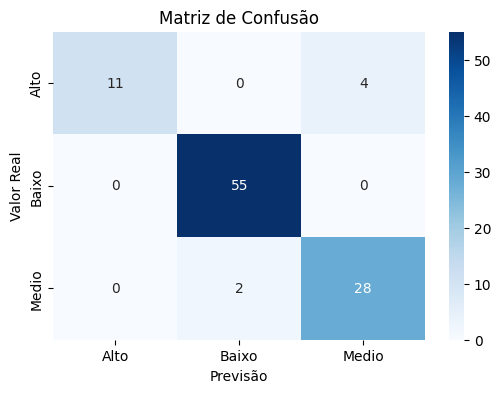

In [37]:
# Matriz de confusão

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=modelo.classes_,
    yticklabels=modelo.classes_
)

plt.title('Matriz de Confusão')
plt.xlabel('Previsão')
plt.ylabel('Valor Real')
plt.show()

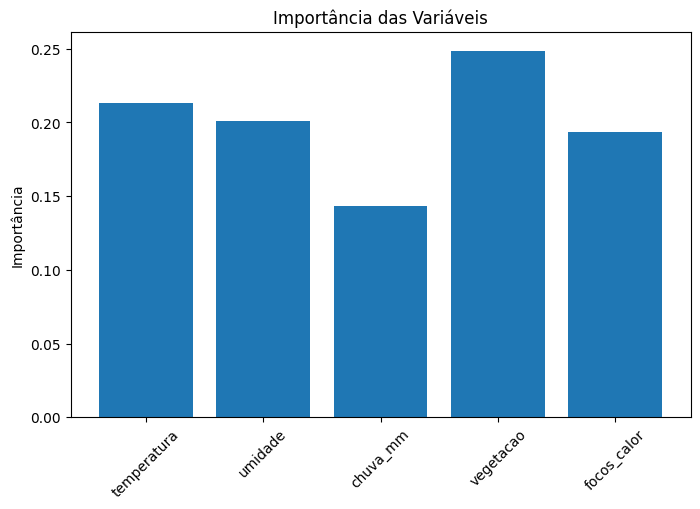

In [38]:
# importância das variáveis

importancias = modelo.feature_importances_

nomes = X.columns

plt.figure(figsize=(8,5))
plt.bar(nomes, importancias)
plt.title('Importância das Variáveis')
plt.ylabel('Importância')
plt.xticks(rotation=45)
plt.show()